# Umbrella sampling and reactive flux calculation for the N<sub>2</sub> dissociation on Fe at 700 K

In this notebook, we analyze an umbrella sampling simulation to study the dissociation of a single N<sub>2</sub> molecule on an iron surface, following the study of [Bonati and co-workers](https://www.pnas.org/doi/10.1073/pnas.2313023120).
After computing the free energy profile, we perform a reactive flux simulation to obtain exact reaction kinetics.

This notebook relies on [ThermoLIB](https://github.com/molmod/Thermolib) 1.8.0

In [56]:
from pathlib import Path

import numpy as np, matplotlib.pyplot as plt
from ase.io import read, write
from ase import units as aseunits

from thermolib.units import * 
from thermolib.constants import *
from thermolib.thermodynamics.fep import SimpleFreeEnergyProfile
from thermolib.thermodynamics.histogram import Histogram1D
from thermolib.tools import read_wham_input, decorrelate, plot_histograms_1d, plot_histograms_overlap_1d
from thermolib.thermodynamics.trajectory import ColVarReader
from thermolib.thermodynamics.cv import Distance
from thermolib.kinetics.rate import RateFactorEquilibrium
from thermolib.thermodynamics.condprob import ConditionalProbability1D1D


## Free energy calculation
The weighted histogram analysis method (WHAM) is used to compute the reaction free energy profile (FEP) along the chosen CV by combining the simulations from the different umbrellas.

In [2]:
# read in the collective variable values and the biasses parameters
colvar_reader = ColVarReader([1], units=["angstrom"])

wham_input = Path.cwd() / "umbrella_sampling/wham_input.txt"
temp, biasses, trajectories = read_wham_input(
    wham_input,
    colvar_reader, 
    "%s/COLVAR",
    bias_potential="Parabola1D",
    q01_unit="angstrom",
    kappa1_unit="kjmol/angstrom**2",
)

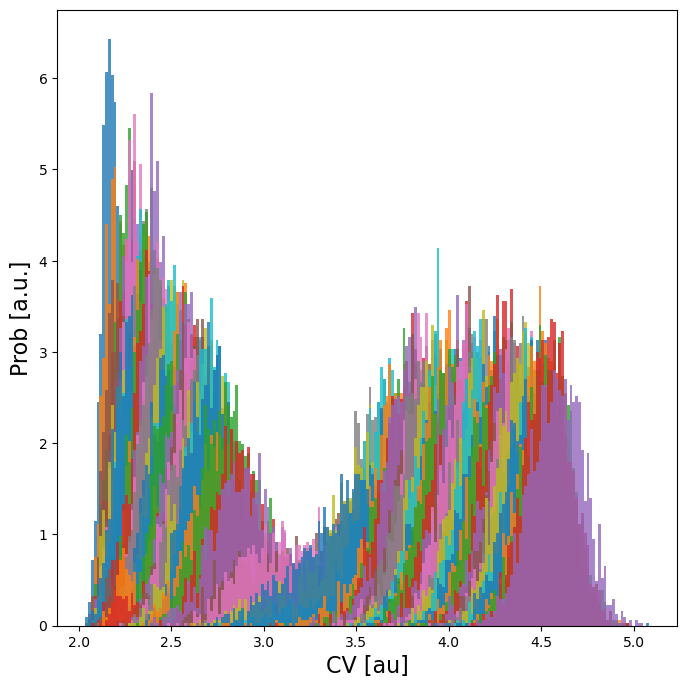

In [3]:
# inspect the overlap between histograms
plot_histograms_1d(trajectories)

<Figure size 640x480 with 0 Axes>

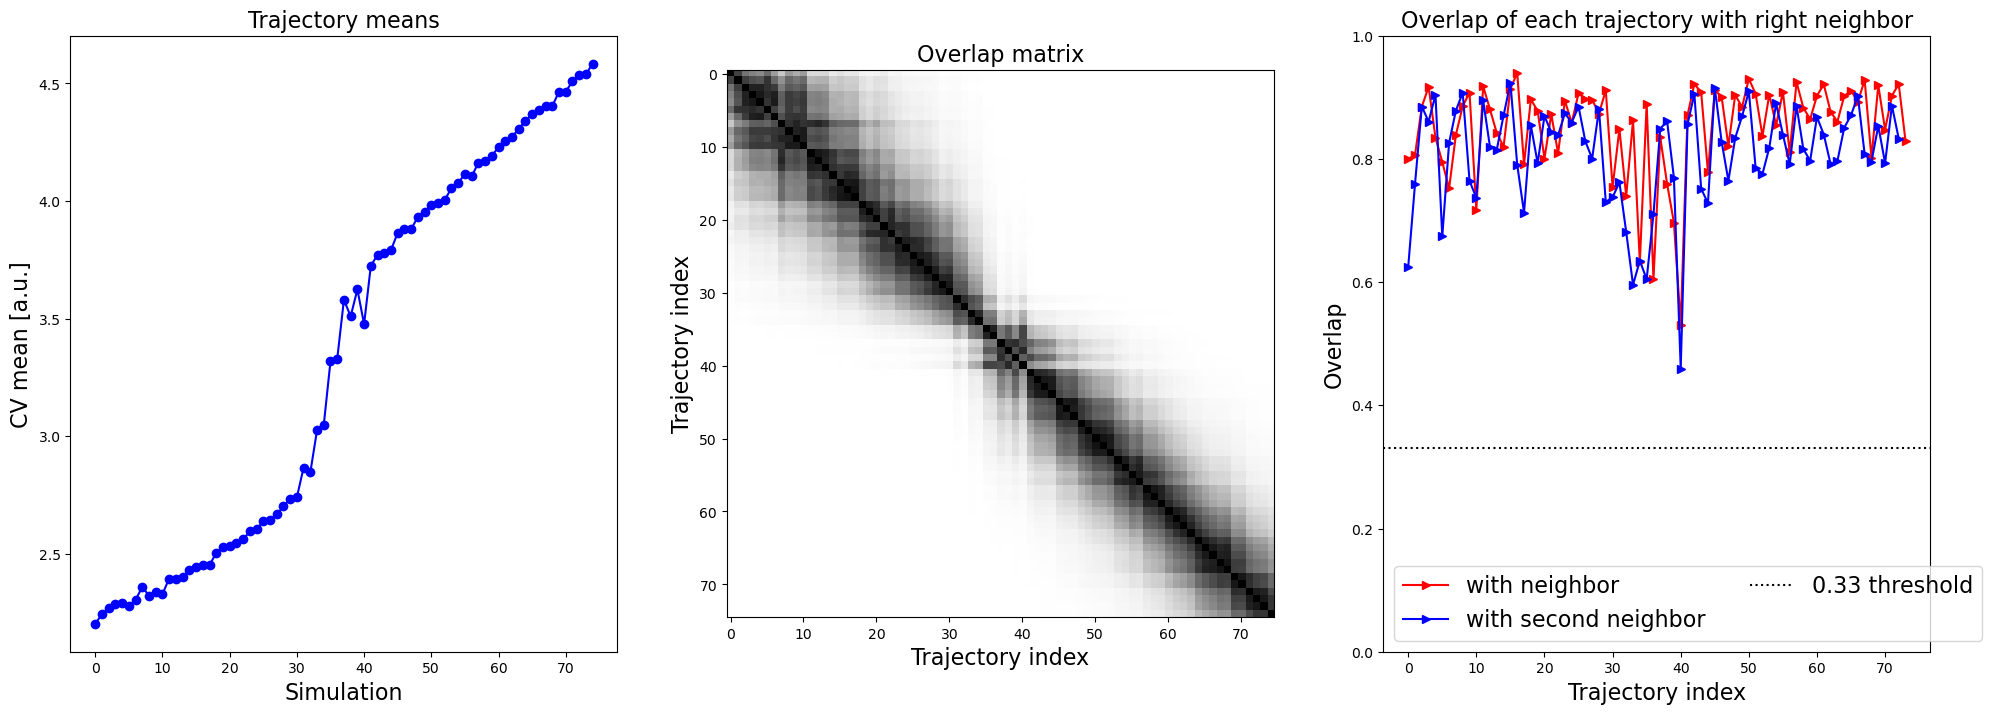

In [4]:
# quantitatively evaluate the overlap between the trajectories
plot_histograms_overlap_1d(trajectories)

<Figure size 640x480 with 0 Axes>

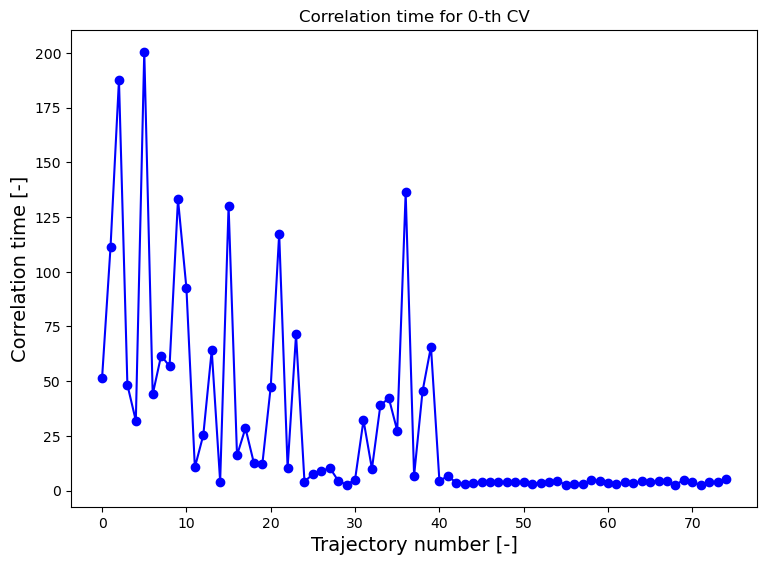

SCF Converged!
---------------------------------------------------------------------
TIMING SUMMARY
  initializing: 00h 00m 00.000s
  histograms  : 00h 00m 00.003s
  bias poten. : 00h 00m 00.031s
  solve scf   : 00h 00m 00.013s
  error est.  : 00h 00m 00.008s
  TOTAL       : 00h 00m 00.056s
---------------------------------------------------------------------


In [ ]:
# use wham to construct the full histogram from the various simulations, including error estimation
bins = np.linspace(2.0, 5.0, 100)
corrtimes = decorrelate(trajectories, plot=True) # decorrelate the trajectory frames
hist = Histogram1D.from_wham(
    bins, 
    trajectories, 
    biasses, 
    temp, 
    Nscf=10000,
    corrtimes=corrtimes,
    error_estimate='mle_f_cov',
)

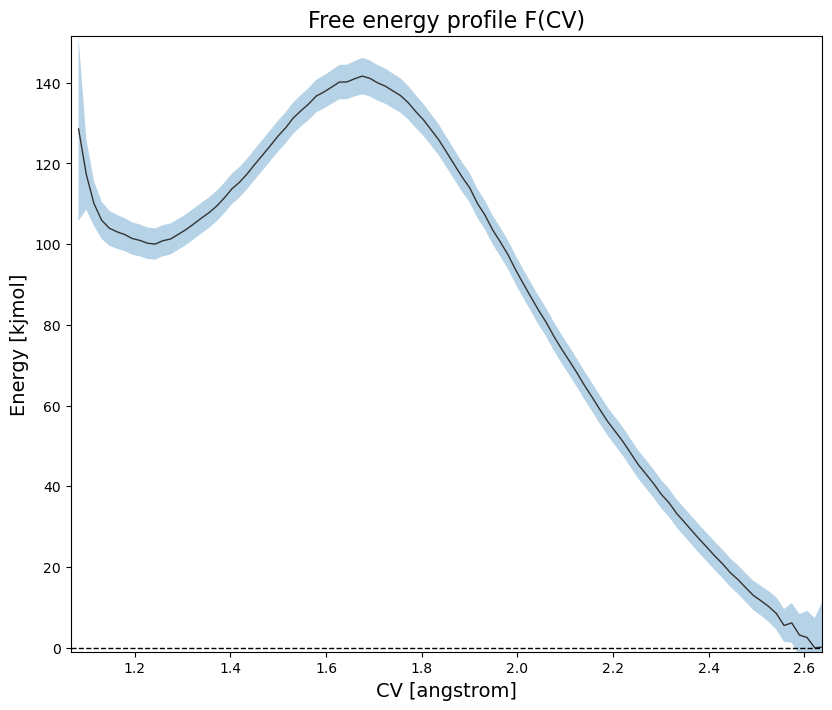

In [6]:
# construct the final free energy profile from the histogram
fep = SimpleFreeEnergyProfile.from_histogram(hist, temp=temp, cv_output_unit="angstrom")
fep.set_ref("min")
fep.plot()

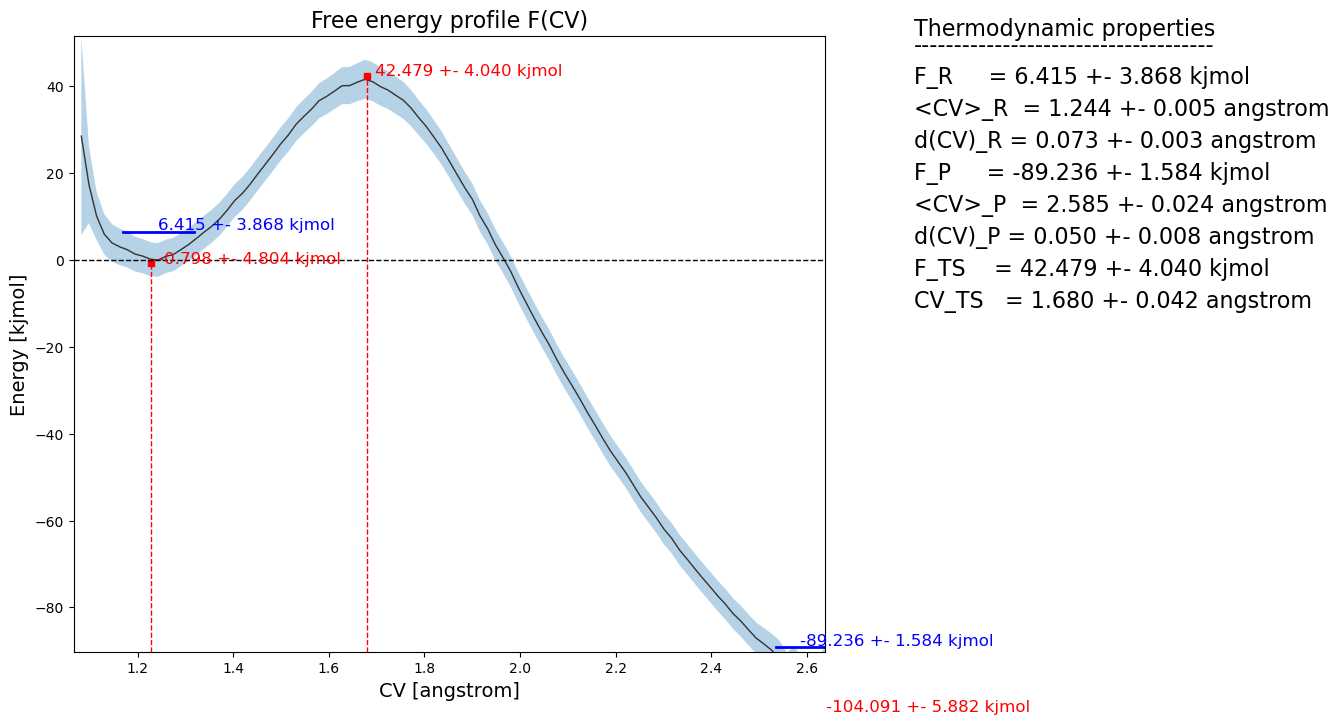

In [7]:
# identify the transition state and the reactants/products regions
fep.process_states(lims=[-np.inf,3.0,4.0,np.inf], verbose=False)
fep.set_ref('r')
fep.plot()

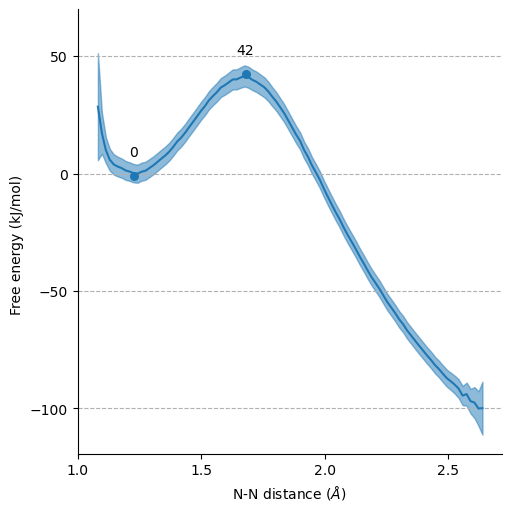

In [ ]:
# fancy FEP plot
fig, axs = plt.subplots(figsize=(5,5), layout="constrained")
color = plt.get_cmap("tab10")(0)

axs.plot(fep.cvs/angstrom, fep.fs/kjmol, color=color)
axs.fill_between(fep.cvs/angstrom, fep.error.nsigma_conf_int(2)[0]/kjmol, fep.error.nsigma_conf_int(2)[1]/kjmol, alpha=0.5, color=color)
# label microstates
for microstate in fep.microstates[:-1]:
    axs.scatter(microstate.get_cv()/angstrom, microstate.get_F()/kjmol, s=30, zorder=10, color=color)
    axs.annotate(int(microstate.get_F()/kjmol), (microstate.get_cv()/angstrom, microstate.get_F()/kjmol+10), ha='center', va='center', fontsize=10)

# Remove top and right spines
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

# Set the range for the left and bottom spines
axs.spines['left'].set_bounds(-120, 70)  # Adjust as needed

axs.set_yticks([-100, -50, 0, 50])
axs.set_xticks([1.0, 1.5, 2.0, 2.5])

axs.grid(axis="y", linestyle="--")

axs.set_xlabel(r"N-N distance ($\AA$)")
axs.set_ylabel("Free energy (kJ/mol)")

fig.savefig(Path.cwd() / "figures/fep.png", dpi=300)

## Free energy deprojections and transformations
To obtain further details on the reaction mechanism, it can be interesting to 'observe' the reaction free energy along additional collective variables. Here, we first convert the original CV into a new CV using a coordination number (CN), to show the FEP dependence on the chosen CV. Since the CN is an analytical function of the distance, the transformation can be done analytically as well:
$$
\text{CN}(i; j) = \frac{1 - (\frac{r_{i,j}}{r_0})^n}{1 - (\frac{r_{i,j}}{r_0})^m}
$$

In [45]:
def CN(r, r0=1.8*angstrom, nn=8, mm=16):
    """
    The coordination number between two atoms that are at a certain distance d.
    """
    return (1 - (r / r0)**nn) / (1 - (r / r0)**mm)

def derivative(r, r0=1.8*angstrom, nn=8, mm=16):
    """
    The derivative d(CN)/d(r)
    """
    T = (nn - mm) * (r /  r0)**(nn + mm - 1) + mm * (r / r0)**(mm - 1) - nn * (r / r0)**(nn - 1)
    N = (1 - (r / r0)**mm)**2
    dCN_dr = (1. / r0) * T / N
    return dCN_dr

In [ ]:
# transform the FEP from distance to CN. We can do this analytically.
fep_transformed = fep.transform_function(CN, derivative=derivative)
fep_transformed.process_states(lims=[-np.inf,0.3,0.7,np.inf])
fep_transformed.set_ref('p')

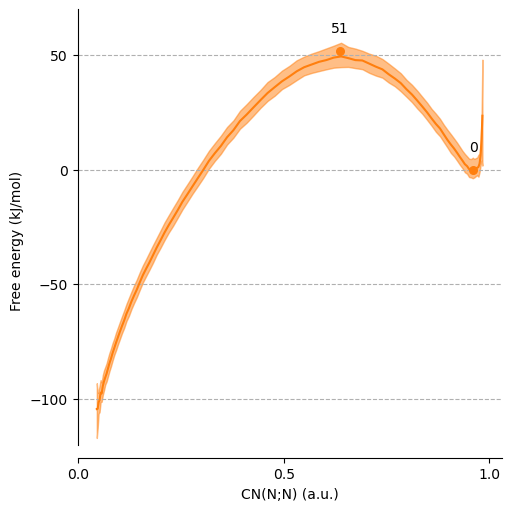

In [ ]:
# fancy FEP plot
fig, axs = plt.subplots(figsize=(5,5), layout="constrained")
color = plt.get_cmap("tab10")(1)

axs.plot(fep_transformed.cvs, fep_transformed.fs/kjmol, color=color)
axs.fill_between(fep_transformed.cvs, fep_transformed.error.nsigma_conf_int(2)[0]/kjmol, fep_transformed.error.nsigma_conf_int(2)[1]/kjmol, alpha=0.5, color=color)
# label microstates
for microstate in fep_transformed.microstates[1:]:
    axs.scatter(microstate.get_cv(), microstate.get_F()/kjmol, s=30, zorder=10, color=color)
    axs.annotate(int(microstate.get_F()/kjmol), (microstate.get_cv(), microstate.get_F()/kjmol+10), ha='center', va='center', fontsize=10)

# Remove top and right spines
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

# Set the range for the left and bottom spines
axs.spines['left'].set_bounds(-120, 70)  # Adjust as needed

axs.set_yticks([-100, -50, 0, 50])
axs.set_xticks([0.0, 0.5, 1.0])

axs.grid(axis="y", linestyle="--")

axs.set_xlabel(r"CN(N;N) (a.u.)")
axs.set_ylabel("Free energy (kJ/mol)")

fig.savefig(Path.cwd() / "figures/fep_transformed.png", dpi=300)

We can see how changing the CV changes the shape of the profile and the height of the barrier, which is clearly not the adequate quantity to compute a reaction rate.

Second, we deproject the FEP along a second CV, the CN between the N atoms and the Fe atoms in the system. This allows to observe how the second CV changes while the reaction progresses.

In this case, the two CVs are not related by an analytical function and the transformation relies, therefore, on a conditional probability computed from the simulation frames.

In [ ]:
# initialize a conditional probability object
condprob = ConditionalProbability1D1D()

# read in the value of the second collective variable from the simulation output
cv2_reader = ColVarReader([3], units=["au"])
umb_idx = 0
while True:
    fn_umb = Path.cwd() / f"umbrella_sampling/U{umb_idx}/COLVAR"
    if not fn_umb.exists(): break

    condprob.process_simulation(
        [(str(fn_umb), cv2_reader)],
        [(str(fn_umb), colvar_reader)],   
    )

    umb_idx += 1

In [ ]:
bins_cv2 = np.linspace(0.0, 5.0, 100) # binning of the new collective variable
condprob.finish([bins_cv2], [bins]) # normalize the probability once the data collection is finished
fep_deprojected = condprob.deproject(fep) # use the conditional probability to deproject fep
fep_deprojected.set_ref('min')

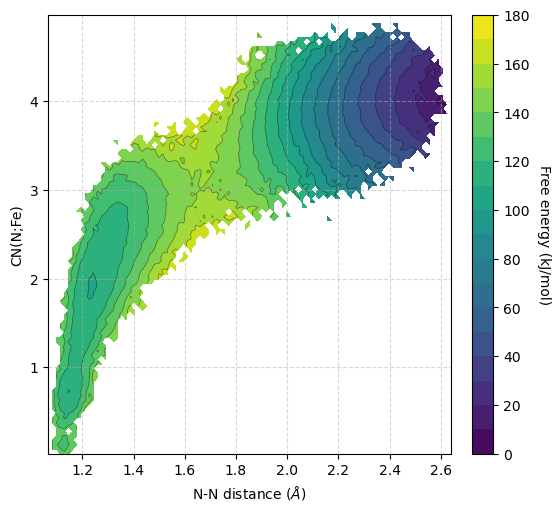

In [ ]:
# fancy free energy profile plot
fig, axs = plt.subplots(figsize=(5.5,5), layout="constrained")

levels = np.arange(0, 190, 10)
cont = axs.contourf(fep_deprojected.cv1s/angstrom, fep_deprojected.cv2s, fep_deprojected.fs.T/kjmol, levels=levels)
axs.contour(fep_deprojected.cv1s/angstrom, fep_deprojected.cv2s, fep_deprojected.fs.T/kjmol, levels=levels, colors="black", alpha=0.5, linewidths=0.5)

axs.set_xlabel(r"N-N distance ($\AA$)")
axs.set_ylabel("CN(N;Fe)")

cbar = plt.colorbar(cont)
cbar.set_label("Free energy (kJ/mol)", rotation=270, labelpad=15)

axs.grid(linestyle='--', alpha=0.5)

plt.savefig(Path.cwd() / "figures/fep_deprojected.png", dpi=300)

Not surprisingly, the CN increases as the reaction progresses since the two N atoms become chemically bonded to the surface. It is also interesting to notice that N<sub>2</sub> does not spontaneously leave the surface during the simulation, due to the lack of states at CN $\sim 0$. 

## Reaction rate constant within the TST approximation
The reaction rate constant is computed within the transition state theory approximation from Bennett-Chandler reaction rate theory. The rate has a thermodynamic factor, i.e. the probability of being atop the transition state compared to the reactant state, and a kinetic factor, i.e. the 'speed' at which the system crosses the transition state.
$$
k_\text{TST} = \sqrt{\frac{k_\text{B} T}{2 \pi}} \langle | \nabla_x q | \rangle_{q = q^\ddagger} \frac{e^{- \beta F (q^\ddagger)}}{\int_{- \infty}^{q^\ddagger} e^{- \beta F(q)} \text{d}q}
$$

In [8]:
# CV definition
atoms = read(Path.cwd() / "umbrella_sampling/U0/md.traj")
N_indices = [i for i, s in enumerate(atoms.get_chemical_symbols()) if s == "N"]
print(N_indices)

dist = Distance(N_indices[0], N_indices[1])

[96, 97]


Transitions state CV value:  1.6798971012578179  angstrom
Closest umbrella to transition state:  36


Text(0, 0.5, 'Histogram count (a.u.)')

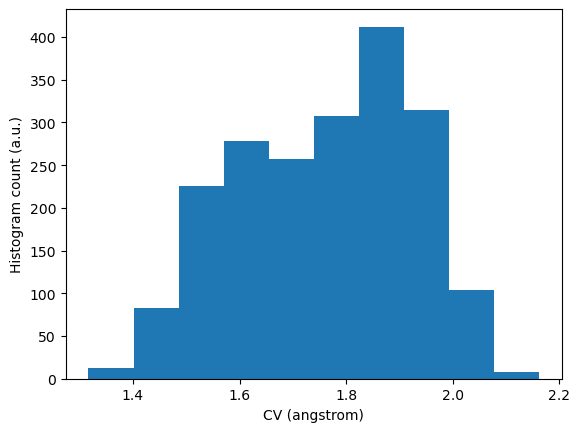

In [9]:
# print the transition state CV value and identify the closest umbrella. 
ts_cv = fep.ts.get_cv() / angstrom
print("Transitions state CV value: ", ts_cv, " angstrom")

# identify the closest umbrella center to the CV value
centers = np.linspace(1.1, 2.3, 75)
ts_umb_idx = np.argmin(np.abs(centers - ts_cv))
print("Closest umbrella to transition state: ", ts_umb_idx)

# plot the CV distribution
colvar = np.loadtxt(Path.cwd() / f"umbrella_sampling/U{ts_umb_idx}/COLVAR")
fig, ax = plt.subplots()
ax.hist(colvar[:,1])
ax.set_xlabel("CV (angstrom)")
ax.set_ylabel("Histogram count (a.u.)")

In [10]:
# initialize the rate object
cv_ts_delta = 0.02 * angstrom
cv_ts_lims = [fep.ts.get_cv() - cv_ts_delta, fep.ts.get_cv() + cv_ts_delta]
rate = RateFactorEquilibrium(dist, cv_ts_lims, temp, CV_unit="angstrom")

# extract samples from the three umbrellas closest to the ts
for umb_idx in [34, 35, 36]:
    fn = Path.cwd() / f"umbrella_sampling/U{umb_idx}/md.xyz"
    rate.process_trajectory(fn, finish=False)
rate.finish() # conclude the rate calculation to normalize the probability distributions

<b>Note:</b> the approach above, where multiple umbrellas are combined, is only fully rigorous in the limit for `cv_ts_delta` $\rightarrow 0$, as otherwise the different biasses in the three umbrellas make the distribution of transition state structures non-canonical. One would either need to use a single umbrella centered on top of the TS (better approximation) or reweight the structure selection based on the bias. Here, for simplicity, we accept the approximation.

<Figure size 640x480 with 0 Axes>

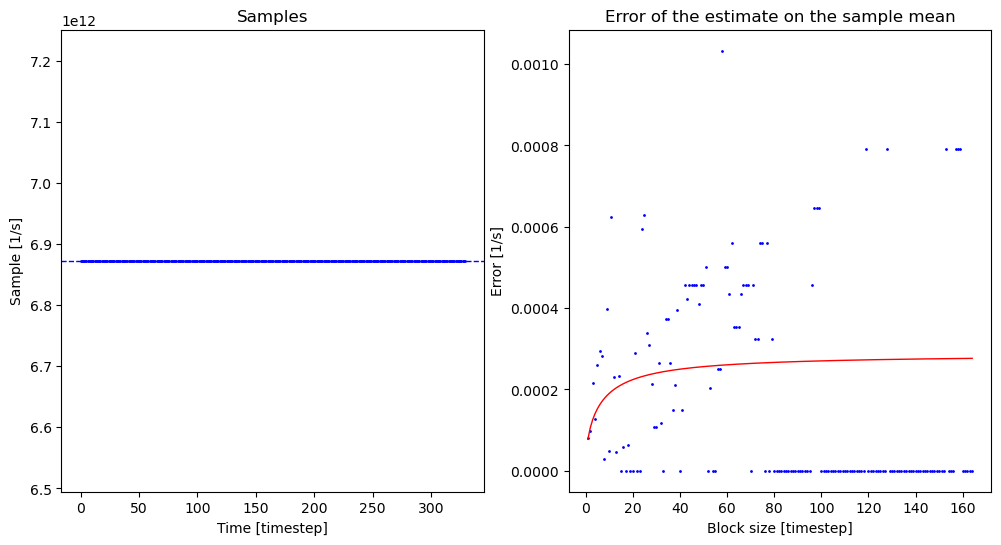

Rate factor with block averaging:
---------------------------------
  A = 3.637 10^+12 +- 5.930 10^-04 angstrom/s (330 TS samples, int. autocorr. time = 13.809 timesteps)



In [ ]:
# compute and plot the samples of the rate prefactor, block averaging can be used to obtain an estimate of the error
A, A_dist = rate.result_blav(plot=True, fitrange=[10,100])

It can be noted that the sampled have here all the same value, which is normal due to the linear relationship between distance and cartesian coordinates.

In [12]:
# compute and print the final rate
rate_results = rate.compute_rate(fep, verbose=True)

k_F  = 4.984 10^+09 <= 1.480 10^+10 <= 3.473 10^+10 1/s
dF_F = 40.804 +- 5.650 kjmol
k_B  = 4.211 10^+02 <= 1.044 10^+03 <= 2.186 10^+03 1/s
dF_B = 136.451 +- 4.792 kjmol


We can see what rate we would have obtained according to the naive min-max free energy difference approach:

In [111]:
# based on CV = distance(N;N)
activation_free_energy = (fep.microstates[1].get_F() - fep.microstates[0].get_F()) 
k_f_d = (boltzmann * fep.T / planck) * np.exp(- activation_free_energy / (boltzmann * fep.T))
print(f"Eyring's rate constant (distance): {k_f_d*second:.3e} 1/s")
activation_free_energy = (fep_transformed.microstates[1].get_F() - fep_transformed.microstates[-1].get_F()) 
k_f_d = (boltzmann * fep.T / planck) * np.exp(- activation_free_energy / (boltzmann * fep.T))
print(f"Eyring's rate constant (CN): {k_f_d*second:.3e} 1/s")

Eyring's rate constant (distance): 8.602e+09 1/s
Eyring's rate constant (CN): 1.957e+09 1/s


## Reactive flux calculation
In a reactive flux calculation, structures are taken within a small interval around the transition state and propagated after providing them with randomized initial velocities. The transmission coefficient can be computed by monitoring the basin of attraction the trajectories committ to.

In [23]:
cv_ts_delta = 0.02
cv_ts_lims = [fep.ts.get_cv()/angstrom - cv_ts_delta, fep.ts.get_cv()/angstrom + cv_ts_delta]

# extract samples from the three umbrellas closest to the ts
ts_structures = []
for umb_idx in [34, 35, 36]:
    fn = Path.cwd() / f"umbrella_sampling/U{umb_idx}/md.xyz"
    traj = read(fn, index=":")
    N_indices = [i for i, s in enumerate(traj[0].get_chemical_symbols()) if s == "N"]
    
    for atoms in traj:
        d = atoms.get_distance(N_indices[0], N_indices[1])
        if d > cv_ts_lims[0] and d < cv_ts_lims[1]:
            ts_structures.append(atoms)

print(f"Extracted {len(ts_structures)} transition state structures.")
write(Path.cwd() / "umbrella_sampling/transition_state_structures.xyz", ts_structures)


Extracted 334 transition state structures.


<b>Note:</b> the approach above is only fully rigorous in the limit for `cv_ts_delta` $\rightarrow 0$, as otherwise the different biasses in the three umbrellas make the distribution of transition state structures non-canonical. One would either need to use a single umbrella centered on top of the TS (better approximation) or reweight the structure selection based on the bias. Here, for simplicity, we accept the approximation.

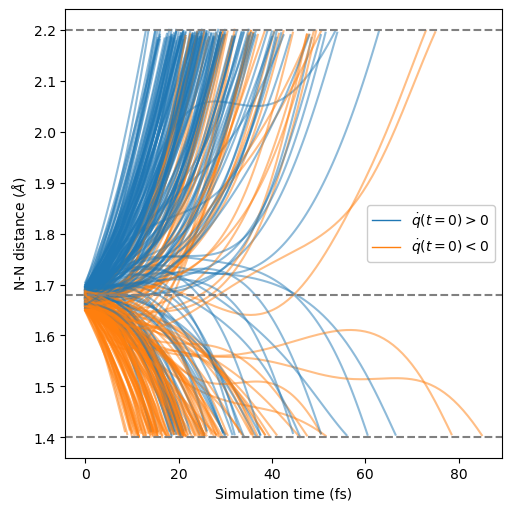

In [122]:
# Plot the time evolution of the reactive flux trajectories
path_rf = Path.cwd() / "reactive_flux/trajectories"

fig, ax = plt.subplots(figsize=(5,5), layout="constrained")

all_q0dot = []
all_q0dot_h = []

i_traj = 0
while True:
    fn_traj = path_rf / f"{i_traj}.txt"
    if not fn_traj.is_file(): break

    traj = np.loadtxt(fn_traj)
    all_q0dot_h.append(traj[:,2])

    # color trajectories based on initial velocity
    q0_dot = traj[0,2]
    all_q0dot.append(q0_dot)
    color = plt.get_cmap("tab10")(0) if q0_dot > 0 else plt.get_cmap("tab10")(1)

    # remove stable states regions
    colvar = traj[:, 1]
    colvar = colvar[colvar > 1.4]
    colvar = colvar[colvar < 2.2]

    # plot the trajectory
    ax.plot(np.arange(len(colvar)) * 0.5, colvar, color=color, alpha=0.5)
    
    i_traj += 1 

all_q0dot, all_q0dot_h = np.array(all_q0dot), np.array(all_q0dot_h)

# decorate the plot
ax.axhline(fep.ts.get_cv()/angstrom, color="grey", linestyle='--')
ax.axhline(2.2, color="grey", linestyle='--')
ax.axhline(1.4, color="grey", linestyle='--')

ax.set_xlabel("Simulation time (fs)")
ax.set_ylabel(r"N-N distance ($\AA$)")

# define two "proxy" line objects for the legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=plt.get_cmap("tab10")(0), lw=1, label=r"$\dot{q}(t=0) > 0$"),
    Line2D([0], [0], color=plt.get_cmap("tab10")(1), lw=1, label=r"$\dot{q}(t=0) < 0$")
]

ax.legend(handles=legend_elements, loc="center right", framealpha=1.0)

fig.savefig(Path.cwd() / "figures/reactive_flux.png", dpi=300)

In [125]:
avg_abs_q0dot = np.mean(np.abs(all_q0dot))
avg_q0dot_h = np.mean(all_q0dot_h, axis=0)

# compare the tst rate constant from thermolib (analytical momenta integration) and rf (numeric momenta)
k_f_TST_thermolib = rate_results[0][0] * second
k_f_TST_rf = 0.5 * avg_abs_q0dot * aseunits.fs * 1E15 * np.exp(-fep.ts.F_dist.mean()[0] / (boltzmann * fep.T)) / (fep.R.Z_dist.mean()[0] / angstrom)

print("TST rate constant with analytical momenta integration: {:.2e} 1/s".format(k_f_TST_thermolib))
print("TST rate constant from RF velocities: {:.2e} 1/s".format(k_f_TST_rf))

# evaluate the transmission coefficient time evolution
kappa_t = 2 * avg_q0dot_h / avg_abs_q0dot

# the correct rate constant
k_f_RF = kappa_t[-1] * k_f_TST_thermolib
print("Correct rate constant including recrossing: {:.2e} 1/s".format(k_f_RF))

TST rate constant with analytical momenta integration: 1.48e+10 1/s
TST rate constant from RF velocities: 1.32e+10 1/s
Correct rate constant including recrossing: 1.17e+10 1/s


We can now plot the transmission coefficient, which is given by the ratio of the true rate constant vs. the TST one. In this case we get a plateau value of 0.8, indicating that the chosen CV is adequately describing the rare event.

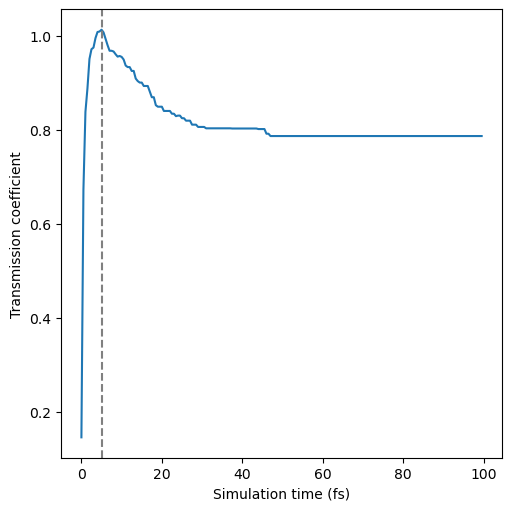

In [127]:
# plot the transmission coefficient
fig, ax = plt.subplots(figsize=(5,5), layout="constrained")

ax.plot(np.arange(len(kappa_t[:200])) * 0.5, kappa_t[:200])
ax.axvline(5, linestyle="--", color="grey")
ax.set_xlabel("Simulation time (fs)")
ax.set_ylabel("Transmission coefficient")

fig.savefig(Path.cwd() / "figures/transmission_coefficient.png", dpi=300)